In [139]:
import seaborn as sns
import numpy as  np 
import pandas as pd 
import matplotlib.pyplot as plt

In [143]:
df = pd.read_csv("../data/silver/cleaned_data.csv")
df.head()

,Page Views,Session Duration,Bounce Rate,Traffic Source,Time on Page,Previous Visits
0,5,11.051381,0.230652,Organic,3.890460,3
1,4,3.429316,0.391001,Social,8.478174,0
2,4,1.621052,0.397986,Organic,9.636170,2
3,5,3.629279,0.180458,Organic,2.071925,3
4,5,4.235843,0.291541,Paid,1.960654,5


In [144]:
df['Avg Time'] = np.where(
    df['Page Views'] > 0,                     
    df['Time on Page'] / df['Page Views'],    
    0                       
)

In [145]:
num_cols = df.select_dtypes(include=['int64', 'float64'])
num_cols.corr(method='spearman')

,Page Views,Session Duration,Bounce Rate,Time on Page,Previous Visits,Avg Time
Page Views,1.000000,-0.007402,0.027002,0.020028,0.026353,-0.462468
Session Duration,-0.007402,1.000000,-0.002325,0.004357,-0.013845,0.014651
Bounce Rate,0.027002,-0.002325,1.000000,0.038775,-0.006956,0.010402
Time on Page,0.020028,0.004357,0.038775,1.000000,-0.039335,0.820153
Previous Visits,0.026353,-0.013845,-0.006956,-0.039335,1.000000,-0.056355
Avg Time,-0.462468,0.014651,0.010402,0.820153,-0.056355,1.000000


In [146]:
df.isnull().sum()

Page Views          0
Session Duration    0
Bounce Rate         0
Traffic Source      0
Time on Page        0
Previous Visits     0
Avg Time            0
dtype: int64

In [108]:
# # Step 2: Return target using last 1 month previous visits and drop Previous vists column due to data leakage 
# df["Return"] = (df["Previous Visits"] > 1).astype(int)
# df = df.drop(columns=["Previous Visits"])

In [ ]:
# t1 = df['Avg Time'].quantile(0.5)
# t2 = df['Avg Time'].quantile(0.75) 
# df['Return'] = ( ((df['Previous Visits'] > 2) & (df['Avg Time'] > t1)) | (df['Avg Time'] > t2) ).astype(int) 
# df = df.drop(columns=["Previous Visits"])
# df = df.drop(columns=["Avg Time"])

In [147]:
t1 = df['Avg Time'].quantile(0.5)
t2 = df['Avg Time'].quantile(0.75) 
df['Return'] = (
    (df['Avg Time'] > t2) |
    ((df['Avg Time'] > t1) & (df['Bounce Rate'] < 0.3))
).astype(int)
df = df.drop(columns=["Avg Time"])
df = df.drop(columns=["Bounce Rate"])

In [148]:
df.describe()

,Page Views,Session Duration,Time on Page,Previous Visits,Return
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,4.950500,3.022045,4.027439,1.978500,0.393000
std,2.183903,3.104518,2.887422,1.432852,0.488539
min,0.000000,0.003613,0.068515,0.000000,0.000000
25%,3.000000,0.815828,1.935037,1.000000,0.000000
50%,5.000000,1.993983,3.315316,2.000000,0.000000
75%,6.000000,4.197569,5.414627,3.000000,1.000000
max,14.000000,20.290516,24.796182,9.000000,1.000000


In [149]:
num_cols = df.select_dtypes(include=['int64', 'float64'])
num_cols.corr(method='spearman')

,Page Views,Session Duration,Time on Page,Previous Visits,Return
Page Views,1.000000,-0.007402,0.020028,0.026353,-0.406554
Session Duration,-0.007402,1.000000,0.004357,-0.013845,0.015497
Time on Page,0.020028,0.004357,1.000000,-0.039335,0.620299
Previous Visits,0.026353,-0.013845,-0.039335,1.000000,-0.049784
Return,-0.406554,0.015497,0.620299,-0.049784,1.000000


In [150]:
percentages = df['Return'].value_counts(normalize=True) * 100
print(percentages)

Return
0    60.7
1    39.3
Name: proportion, dtype: float64


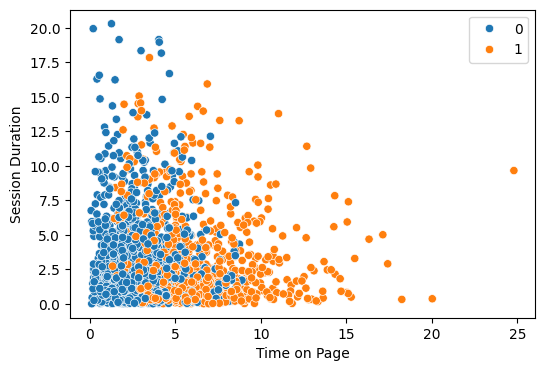

In [151]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='Time on Page',y='Session Duration', hue = 'Return', data= df)
plt.legend()
plt.show()

In [152]:
import plotly.express as px

fig = px.scatter_3d(
    df,
    x='Time on Page',
    y='Page Views',
    z='Session Duration',
    color='Return'   # return vs not return
)

fig.show()

### after seeing the data --- data overlaped

In [25]:
#gold data stores parquet format in gold layer---because parquet format fast , take less size and big data frindly  

#pip install pyarrow---needded environment
 
#df.to_parquet("data/gold/feature_data.parquet", index=False)

In [153]:
df.to_csv("../data/gold/feature_data.csv", index=False)